# Stage 5

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datetime import date, timedelta
import random
import string

from tqdm import tqdm
import matplotlib.pyplot as plt

## Dataset

In [2]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
BATCH_SIZE = 64
SEED = 42

# no peaking into the future !!
START_DATE = date(1990, 1, 1)
END_DATE = date(2030, 12, 31)
TEST_HOLDOUT = 1000
ALL_DATES = [START_DATE + timedelta(days=i)
             for i in range((END_DATE - START_DATE).days + 1)]
random.Random(SEED).shuffle(ALL_DATES)
TRAIN_DATES = ALL_DATES[:-TEST_HOLDOUT]
TEST_DATES = ALL_DATES[-TEST_HOLDOUT:]

SOS = "<"
EOS = ">"
PAD = "_"
tokens = [SOS, EOS, PAD] + list(string.digits + string.ascii_letters + " /,-")
c2i = {c: i for i, c in enumerate(tokens)}
i2c = {i: c for c, i in c2i.items()}
VOCAB_SIZE = len(tokens)

MONTHS = ("January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December")
DATE_FORMATS = ("d/m/yyyy", "dd/mm/yyyy", "Month d, yyyy", "d Mon yyyy")


def render_date(d, format_idx):
    month = MONTHS[d.month - 1]
    return (
        f"{d.day}/{d.month}/{d.year}",
        f"{d.day:02d}/{d.month:02d}/{d.year}",
        f"{month} {d.day}, {d.year}",
        f"{d.day} {month[:3]} {d.year}",
    )[format_idx]


def encode(text):
    return torch.tensor([c2i[c] for c in text], dtype=torch.long)


def decode(ids):
    # Retains special tokens so you can inspect the exact sequence.
    return "".join(i2c[int(i)] for i in ids)

In [3]:
class DateDataset(Dataset):
    def __init__(self, test=False, epoch_size=4096):
        self.test = test
        self.epoch_size = epoch_size
        self.dates = TEST_DATES if test else TRAIN_DATES

    def __len__(self):
        if self.test:
            return len(self.dates) * len(DATE_FORMATS)
        return self.epoch_size

    def _prepare_one(self, d, format_idx):
        x = encode(render_date(d, format_idx))
        y = encode(SOS + d.isoformat() + EOS)
        return x, y

    def _generate_one(self):
        d = self.dates[torch.randint(len(self.dates), ()).item()]
        format_idx = torch.randint(len(DATE_FORMATS), ()).item()
        return self._prepare_one(d, format_idx)

    def __getitem__(self, idx):
        if self.test:
            date_idx, format_idx = divmod(idx, len(DATE_FORMATS))
            return self._prepare_one(self.dates[date_idx], format_idx)
        return self._generate_one()


def right_pad_seqs(batch):
    x, y = zip(*batch)
    # x_lens = torch.tensor([len(s) for s in x])  # not needed here!
    x_padded = pad_sequence(x, batch_first=True, padding_value=c2i[PAD])
    y_padded = pad_sequence(y, batch_first=True, padding_value=c2i[PAD])
    return x_padded, y_padded


torch.manual_seed(SEED)
ds_train = DateDataset()
ds_test = DateDataset(test=True)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, collate_fn=right_pad_seqs)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, collate_fn=right_pad_seqs)

# materialise 10 for repro sake
tiny_examples = [ds_train[i] for i in range(10)]
dl_tiny = DataLoader(tiny_examples, batch_size=10, collate_fn=right_pad_seqs)

In [4]:
for format_idx in range(len(DATE_FORMATS)):
    x, y = ds_train._prepare_one(date(2020, 3, 3), format_idx)
    print(f"{decode(x):20s} -> {decode(y)}")

x, y = next(iter(dl_train))
print("Batch shapes:", x.shape, y.shape)
print("First padded source:", decode(x[0]))
print("First target:", decode(y[0]))

3/3/2020             -> <2020-03-03>
03/03/2020           -> <2020-03-03>
March 3, 2020        -> <2020-03-03>
3 Mar 2020           -> <2020-03-03>
Batch shapes: torch.Size([64, 17]) torch.Size([64, 12])
First padded source: 21 Mar 2029______
First target: <2029-03-21>


## Model

Start with scaled dot-product attention and its reference check.

In [5]:
class SelfAttentionSingleHead(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.d = d
        self.K = nn.Linear(d, d, bias=False)
        self.Q = nn.Linear(d, d, bias=False)
        self.V = nn.Linear(d, d, bias=False)

    def forward(self, x, src_mask):
        # x is (B, T, d)

        keys = self.K(x)
        queries = self.Q(x)
        values = self.V(x)

        # key-query affinities
        e = queries @ torch.transpose(keys, -1, -2)
        e /= self.d**0.5  # "scaled" part
        e.masked_fill_(~src_mask.unsqueeze(1), -torch.inf)

        # attention weights
        alpha = torch.softmax(e, dim=-1)

        outputs = alpha @ values

        return outputs


class SelfAttentionMultiHead(nn.Module):
    def __init__(self, d: int, h, masked: bool = False):
        super().__init__()

        assert h > 0
        assert d % h == 0
        self.h = h
        self.d = d
        self.d_h = d // h
        self.masked = masked

        # assume d_h = d/h
        self.K = nn.Linear(d, d, bias=False)
        self.Q = nn.Linear(d, d, bias=False)
        self.V = nn.Linear(d, d, bias=False)
        self.W0 = nn.Linear(d, d, bias=False)

    def forward(self, x, src_mask):
        # x is (B, T, d)
        B, T, d = x.shape

        keys = self.K(x).view(B, T, self.h, self.d_h).transpose(1, 2)
        queries = self.Q(x).view(B, T, self.h, self.d_h).transpose(1, 2)
        values = self.V(x).view(B, T, self.h, self.d_h).transpose(1, 2)

        # key-query affinities
        e = queries @ torch.transpose(keys, -1, -2)  # (B, H, T, T)
        e /= self.d_h**0.5  # "scaled" part, now by d_h
        e.masked_fill_(~src_mask.unsqueeze(1).unsqueeze(1), -torch.inf)

        # causal/masking here!
        # make all "future" positions in the affinities be -inf
        if self.masked:
            causal_mask = (
                ~torch.tril(torch.ones((T, T), dtype=torch.bool))
                .unsqueeze(0)
                .unsqueeze(0)
            ).to(x.device)
            e.masked_fill_(causal_mask, -torch.inf)

        # attention weights
        alpha = torch.softmax(e, dim=-1)

        outputs = alpha @ values
        outputs.transpose_(1, 2)  # (B, H, T, d_h) -> (B, T, H, d_h)
        outputs = torch.reshape(outputs, (B, T, -1))
        outputs = self.W0(outputs)

        return outputs


class CrossAttentionMultiHead(nn.Module):
    def __init__(self, d: int, h):
        super().__init__()

        assert h > 0
        assert d % h == 0
        self.h = h
        self.d = d
        self.d_h = d // h

        # assume d_h = d/h
        self.K = nn.Linear(d, d, bias=False)
        self.Q = nn.Linear(d, d, bias=False)
        self.V = nn.Linear(d, d, bias=False)
        self.W0 = nn.Linear(d, d, bias=False)

    def forward(self, x, src_mask, x_enc):
        # x is (B, T, d)
        B, T, d = x.shape
        _, S, _ = x_enc.shape  # x_enc may (will) have diff seq lengths

        keys = self.K(x_enc).view(B, S, self.h, self.d_h).transpose(1, 2)
        queries = self.Q(x).view(B, T, self.h, self.d_h).transpose(1, 2)
        values = self.V(x_enc).view(B, S, self.h, self.d_h).transpose(1, 2)

        # key-query affinities
        e = queries @ torch.transpose(keys, -1, -2)  # (B, H, T, S)
        e /= self.d_h**0.5  # "scaled" part, now by d_h
        e.masked_fill_(~src_mask.unsqueeze(1).unsqueeze(1), -torch.inf)

        # attention weights
        alpha = torch.softmax(e, dim=-1)

        outputs = alpha @ values
        outputs.transpose_(1, 2)  # (B, H, T, d_h) -> (B, T, H, d_h)
        outputs = torch.reshape(outputs, (B, T, -1))
        outputs = self.W0(outputs)

        return outputs


class EncoderBlock(nn.Module):
    def __init__(self, d: int):
        super().__init__()

        # 1. attn
        self.attn = SelfAttentionMultiHead(d, h=4)

        # 2. residual + layernorm
        self.ln1 = nn.LayerNorm(d)

        # 3. ff
        d_ff = d * 4
        self.ff1 = nn.Linear(d, d_ff)
        self.ff2 = nn.Linear(d_ff, d)

        # 4. residual + layernorm
        self.ln2 = nn.LayerNorm(d)  # just over feature dim

    def forward(self, x, src_mask):
        x1 = self.attn(x, src_mask)
        x2 = self.ln1(x + x1)

        x3 = self.ff2(torch.relu(self.ff1(x2)))

        x4 = self.ln2(x2 + x3)

        return x4


class DecoderBlock(nn.Module):
    def __init__(self, d: int):
        super().__init__()

        # 1. causal/masked self attn
        self.causal_attn = SelfAttentionMultiHead(d, h=4, masked=True)

        # 2. res + layer norm
        self.ln1 = nn.LayerNorm(d)

        # 3. multi head cross attn
        self.cross_attn = CrossAttentionMultiHead(d, h=4)

        # 4. res + layer norm
        self.ln2 = nn.LayerNorm(d)

        # 5. ff
        d_ff = d * 4
        self.ff1 = nn.Linear(d, d_ff)
        self.ff2 = nn.Linear(d_ff, d)

        # 6. residual + layernorm
        self.ln3 = nn.LayerNorm(d)

    def forward(self, x, x_enc, src_mask, target_mask):
        x1 = self.causal_attn(x, target_mask)
        x2 = self.ln1(x + x1)

        # cross !
        x3 = self.cross_attn(x2, src_mask, x_enc)

        x4 = self.ln2(x2 + x3)

        x5 = self.ff2(torch.relu(self.ff1(x4)))

        x6 = self.ln3(x4 + x5)

        return x6


class MyTransformer(nn.Module):
    def __init__(
        self,
        embedding_size: int = 16,
        n_enc_blocks: int = 2,
        n_dec_blocks: int = 2,
        max_ctx: int = 32,
    ):
        super().__init__()
        self.embedding_size = embedding_size
        self.n_enc_blocks = n_enc_blocks
        self.n_dec_blocks = n_dec_blocks
        self.max_ctx = max_ctx

        # emb
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)

        # positional encoding
        self.register_buffer("pos_enc", self._build_pos_enc())

        # enc
        self.enc_blocks = nn.ModuleList([])
        for _ in range(n_enc_blocks):
            self.enc_blocks.append(EncoderBlock(d=self.embedding_size))

        # dec
        self.dec_blocks = nn.ModuleList([])
        for _ in range(n_dec_blocks):
            self.dec_blocks.append(DecoderBlock(d=self.embedding_size))

        # final layer
        self.ff = nn.Linear(embedding_size, VOCAB_SIZE)

    def _build_pos_enc(self):
        # build out (n, d) matrix with just row index in each col (numerator)
        r = torch.arange(1, self.max_ctx + 1)
        pos_enc = torch.vstack([r for _ in range(self.embedding_size)]).T

        # the denominator, 10K comes from the orginal paper
        col = 10_000 ** (
            2 * (torch.arange(0, self.embedding_size) // 2) / self.embedding_size
        )

        # form the fraction within each trig function
        pos_enc = pos_enc / col.repeat(self.max_ctx).view(
            self.max_ctx, self.embedding_size
        )

        # apply to alternating columms
        pos_enc[:, ::2].sin_()
        pos_enc[:, 1::2].cos_()

        return pos_enc

    def forward(self, x, y):
        """
        - x: (B, S) integer character IDs, right-padded with PAD; no source SOS/EOS.
        - y: (B, 12) containing <YYYY-MM-DD>. All targets have the same length.
        """
        decoder_input = y[:, :-1]  # drop last token ">"
        
        B, S = x.shape
        _, T = decoder_input.shape


        # establish masks from x and y here
        src_mask = x != c2i[PAD]
        target_mask = decoder_input != c2i[PAD]

        # Encoder
        x_enc = self.emb(x) + self.pos_enc[:S, :]
        for enc in self.enc_blocks:
            x_enc = enc(x_enc, src_mask)

        # Decoder
        x_dec = self.emb(decoder_input) + self.pos_enc[:T, :]
        for dec in self.dec_blocks:
            x_dec = dec(x_dec, x_enc, src_mask, target_mask)

        out = self.ff(x_dec)

        return out

## Training time!

In [6]:
def get_test_loss(model, dl_test):
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in dl_test:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            y_pred = model(x, y)

            # flatten
            logits = y_pred.flatten(0, 1)  # (B, T, VOCAB_SIZE) -> (B * T, -1)
            labels = y[:, 1:].flatten()  # skip first token "<" then -> (B * T,)
            loss = loss_fn(logits, labels)

            total_loss += loss * x.size(0)
    return (total_loss / len(dl_test.dataset)).item()


def train(
    model: nn.Module, dl_train: DataLoader, dl_test: DataLoader, n_epochs: int = 10
):
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    pbar = tqdm(range(n_epochs))

    train_losses = []
    test_losses = []
    for _ in pbar:
        total_loss = 0
        model.train()
        for x, y in dl_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optim.zero_grad()
            y_pred = model(x, y)

            # flatten
            logits = y_pred.flatten(0, 1)  # (B, T, VOCAB_SIZE) -> (B * T, -1)
            labels = y[:, 1:].flatten()  # skip first token "<" then -> (B * T,)
            loss = loss_fn(logits, labels)

            loss.backward()
            optim.step()

            total_loss += loss.detach() * x.size(0)

        avg_loss = (total_loss / len(dl_train.dataset)).item()
        train_losses.append(avg_loss)
        test_loss = get_test_loss(model, dl_test)
        test_losses.append(test_loss)
        pbar.set_postfix({"Train loss": avg_loss})

    return train_losses, test_losses


def inspect_some(model: MyTransformer, dl: DataLoader):
    """inspect one batch"""
    was_training = model.training
    model.eval()
    with torch.no_grad():
        x, y = next(iter(dl))
        pred = model(x.to(DEVICE), y.to(DEVICE)).argmax(dim=-1).cpu()
        labels = y[:, 1:]

        for src, target, guess in zip(x, labels, pred):
            print("Input: ", decode(src[src != c2i[PAD]]))
            print("Target:", decode(target))
            print("Pred:  ", decode(guess))
            print()

    model.train(was_training)

## try some training

100%|██████████| 200/200 [00:03<00:00, 54.24it/s, Train loss=0.271]


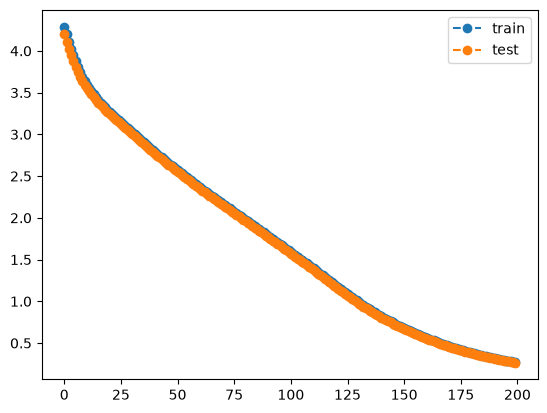

Input:  21 Dec 1998
Target: 1998-12-21>
Pred:   1998-12-21>

Input:  March 13, 2023
Target: 2023-03-13>
Pred:   2023-03-13>

Input:  28 May 1990
Target: 1990-05-28>
Pred:   1990-05-28>

Input:  31/8/1992
Target: 1992-08-31>
Pred:   1992-08-31>

Input:  19/06/2004
Target: 2004-06-19>
Pred:   2004-06-19>

Input:  March 2, 1998
Target: 1998-03-02>
Pred:   1998-03-02>

Input:  January 29, 1998
Target: 1998-01-29>
Pred:   1998-01-29>

Input:  5/2/2029
Target: 2029-02-05>
Pred:   2029-02-05>

Input:  14 Apr 2021
Target: 2021-04-14>
Pred:   2021-04-14>

Input:  April 24, 1997
Target: 1997-04-24>
Pred:   1997-04-24>



In [7]:
model = MyTransformer().to(DEVICE)

# can we overfit?

train_losses, test_losses = train(model, dl_tiny, dl_tiny, n_epochs=200)
plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

inspect_some(model, dl_tiny)

100%|██████████| 50/50 [00:57<00:00,  1.15s/it, Train loss=0.00085]


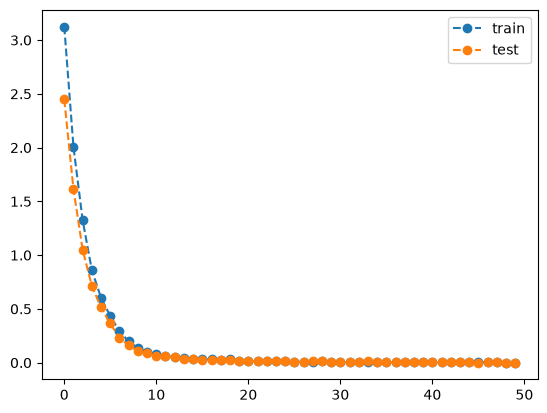

In [8]:
## OK let's really train it now

model = MyTransformer().to(DEVICE)

train_losses, test_losses = train(model, dl_train, dl_test, n_epochs=50)
plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

In [9]:
inspect_some(model, dl_test)

Input:  12/6/2009
Target: 2009-06-12>
Pred:   2009-06-12>

Input:  12/06/2009
Target: 2009-06-12>
Pred:   2009-06-12>

Input:  June 12, 2009
Target: 2009-06-12>
Pred:   2009-06-12>

Input:  12 Jun 2009
Target: 2009-06-12>
Pred:   2009-06-12>

Input:  26/9/1994
Target: 1994-09-26>
Pred:   1994-09-26>

Input:  26/09/1994
Target: 1994-09-26>
Pred:   1994-09-26>

Input:  September 26, 1994
Target: 1994-09-26>
Pred:   1994-09-26>

Input:  26 Sep 1994
Target: 1994-09-26>
Pred:   1994-09-26>

Input:  28/12/2011
Target: 2011-12-28>
Pred:   2011-12-28>

Input:  28/12/2011
Target: 2011-12-28>
Pred:   2011-12-28>

Input:  December 28, 2011
Target: 2011-12-28>
Pred:   2011-12-28>

Input:  28 Dec 2011
Target: 2011-12-28>
Pred:   2011-12-28>

Input:  21/11/2026
Target: 2026-11-21>
Pred:   2026-11-21>

Input:  21/11/2026
Target: 2026-11-21>
Pred:   2026-11-21>

Input:  November 21, 2026
Target: 2026-11-21>
Pred:   2026-11-21>

Input:  21 Nov 2026
Target: 2026-11-21>
Pred:   2026-11-21>

Input:  4/11/

## now let's get rid of teacher forcing and evaluate

In [52]:
def get_really_strict_test_accuracy(model: nn.Module, dl_test: DataLoader):
    """l;ike get_test_loss but we don't do teacher forcing, and we check just a
    binary accuracy for each sequence.
    """

    model.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in dl_test:
            B, T = x.shape
            _, S = y.shape

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            # now to get some parallelism, we can use the fact that each
            # output seq. is of the same length, so we just run max length
            # of decode steps across the batch and don't have to do anything special

            y_pred = torch.zeros((B, S), dtype=torch.long).to(DEVICE)
            y_pred[:, 0] = c2i[SOS]  # initialise the output sequences with SOS (or BOS)

            # run S - 1 steps, as we don't need to decode for SOS
            for i in range(S - 1):

                logits = model(x, y_pred)
                next_tokens = logits[:, i, :].argmax(dim=-1)
                y_pred[:, i + 1] = next_tokens

            # now check if we got the exact same sequences
            total_correct += (y == y_pred).all(dim=1).sum().item()

    return total_correct / len(dl_test.dataset)

In [53]:
get_really_strict_test_accuracy(model, dl_test)

1.0

100% !!